In [1]:
import pandas as pd
import numpy as np
file_path = r"C:\Users\prodd\Downloads\GSAF5.xlsx"
sharks = pd.read_excel(file_path)

In [2]:
sharks = sharks.drop(['pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22', 'Injury', 'Species ','Name'], axis=1)

In [3]:
sharks['Age'] = sharks['Age'].astype(str)


# Convert '30+' and similar formats
sharks['Age'] = sharks['Age'].apply(lambda x: x.replace('+', '') if '+' in x else x)

# Replace '?' with NaN 
sharks['Age'] = sharks['Age'].replace('?', np.nan)

# At this point, convert the column to numeric, coercing errors into NaN
sharks['Age'] = pd.to_numeric(sharks['Age'], errors='coerce')

# fill NaN with the mean age 
mean_age = sharks['Age'].mean()
sharks['Age'] = sharks['Age'].fillna(mean_age)
sharks['Age'] = sharks['Age'].astype(int)
sharks['Age']

0       57
1        8
2        8
3       28
4       63
        ..
7040    28
7041    28
7042    28
7043    28
7044    15
Name: Age, Length: 7045, dtype: int64

In [4]:
fatal_mapping = fatal_mapping = {
    ' N':'N',  'n':'N', 'Nq':'N', 'N':'N', 'N ':'N',
    2017:'Y', 'Y x 2':'Y', 'y':'Y', 'F':'Y', 'M':'Y'
}

sharks['Fatal Y/N'] = sharks['Fatal Y/N'].map(fatal_mapping).fillna(sharks['Fatal Y/N'])

sharks['Fatal Y/N'].value_counts()



Fatal Y/N
N          4920
Y          1493
UNKNOWN      71
Name: count, dtype: int64

In [5]:
nan_count = sharks['Fatal Y/N'].isnull().sum()
nan_count

np.int64(561)

In [6]:
sex_mapping = sex_mapping = {
    'M':'M',' M':'M','M ':'M','m':'M', 'M x 2':'M', 'N':'M',
    'F':'F', 'F ':'F', '.':'F', 'lli':'F'
}

sharks['Sex'] = sharks['Sex'].map(sex_mapping).fillna(sharks['Sex'])

sharks['Sex'].value_counts()

Sex
M    5657
F     809
Name: count, dtype: int64

In [7]:
sharks['Sex'].unique()

array(['M', 'F', nan], dtype=object)

In [8]:
nan_count = sharks['Sex'].isnull().sum()
nan_count

np.int64(579)

In [9]:
sharks['Year'] = sharks['Year'].astype(str).str.replace(r'\.0$', '', regex=True)

# Step 2: Replace or fill NaNs if necessary before converting
sharks['Year'] = sharks['Year'].replace('nan', np.nan)  # Ensure 'nan' strings become actual NaNs
sharks['Year'] = sharks['Year'].ffill()  # Forward fill NaNs; choose a method to handle them

# Step 3: Convert 'Year' to integer type (Optionally, nullable integer dtype)
sharks['Year'] = sharks['Year'].astype('Int64')
sharks = sharks[(sharks['Year'] >= 1950) & (sharks['Year'] <= 2025)]

In [10]:
sharks

,Date,Year,Type,Country,State,Location,Activity,Sex,Age,Fatal Y/N,Time,Source
0,6th September,2025,Unprovoked,Australia,NSW,Long Reef Sydney,Surfing,M,57,Y,0930hrs,Todd Smith: Andy Currie: Simon De Marchi: Kevi...
1,1st September,2025,Unprovoked,USA,Florida,Horseshoe reef Key Largo,Snorkeling,M,8,N,1524hrs,Todd Smith: US SUN: NY Post: The Guardian: Peo...
2,30th August,2025,Unprovoked,USA,Texas,Galveston,Swimming,F,8,N,Not stated,Bob Myatt GSAF : People:
3,18th August,2025,Unprovoked,Australia,NSW,Cabarita Beach,Surfing,M,28,N,0730hrs,Bob Myatt GSAF The Guardian: 9 News: ABS News:...
4,17th August,2025,Unprovoked,Bahamas,Atlantic Ocean near Big Grand Cay,North of Grand Bahama near Freeport,Spearfishing,M,63,N,1300hrs,Ralph Collier GSAF and Kevin MCMurray Tracking...
...,...,...,...,...,...,...,...,...,...,...,...,...
5223,Summer 1950,1950,Unprovoked,GREECE,NaN,"Piraeus, Athens",Swimming,NaN,28,Y,NaN,"V.M. Coppleson (1958), p.259; L. Schultz & M. ..."
5224,1950,1950,Unprovoked,SINGAPORE,Singapore Harbor,NaN,Diving for coins,M,28,Y,NaN,"V.M. Coppleson (1958), p.148"
5225,1950,1950,Unprovoked,NEW CALEDONIA,North Province,"Voh, near meatworks","Spearfishing, but walking carrying fish on end...",M,28,N,NaN,"V.M. Coppleson (1958), p.262; V.M. Coppleson (..."
5226,Ca. 1950,1950,Unprovoked,NEW CALEDONIA,North Province,Mangalia Reef above Touho,"Helmet diving, collecting trochus shell",M,28,N,NaN,"V.M. Coppleson (1958), pp.98 & 262"


In [11]:
sharks['Age'].mean()

np.float64(28.53147120719342)

In [12]:
sharks['Age'].median()

28.0

In [13]:
sharks['Age'].mode()

0    28
Name: Age, dtype: int64

In [14]:
sharks.groupby('Year').size()

Year
1950     43
1951     32
1952     29
1953     36
1954     45
       ... 
2021    110
2022     98
2023    109
2024     52
2025     51
Length: 76, dtype: int64

In [15]:
grouped_attacks = sharks.groupby(['Year', 'Age', 'Sex']).size().reset_index(name='Count')
grouped_attacks

,Year,Age,Sex,Count
0,1950,11,M,1
1,1950,14,M,1
2,1950,16,M,1
3,1950,17,M,1
4,1950,18,M,1
...,...,...,...,...
2411,2025,58,M,1
2412,2025,63,M,1
2413,2025,66,M,2
2414,2025,69,M,1


In [16]:
last_10_years = grouped_attacks[(grouped_attacks['Year'] >= 2015) & (grouped_attacks['Year'] <= 2025)]
last_10_years

,Year,Age,Sex,Count
1828,2015,6,M,1
1829,2015,7,F,1
1830,2015,9,F,2
1831,2015,9,M,2
1832,2015,10,F,1
...,...,...,...,...
2411,2025,58,M,1
2412,2025,63,M,1
2413,2025,66,M,2
2414,2025,69,M,1


In [17]:
sharks['Activity'] = sharks['Activity'].str.lower().str.strip()


def categorize_activity(activity):
    if pd.isna(activity):
        return 'Unknown'
    
    if 'surf' in activity:
        return 'surfing'
    elif 'snorkel' in activity:
        return 'snorkeling'
    elif 'swim' in activity or 'bath' in activity:
        return 'swimming'
    elif 'fish' in activity or 'spear' in activity or 'angl' in activity or 'kayak fish' in activity:
        return 'fishing'
    elif 'dive' in activity or 'scuba' in activity or 'free diving' in activity:
        return 'diving'
    elif 'wade' in activity:
        return 'wading'
    elif 'board' in activity or 'boogie board' in activity or 'paddleboard' in activity:
        return 'boarding'
    elif 'kayak' in activity or 'canoe' in activity:
        return 'kayaking'
    elif 'standing' in activity or 'floating' in activity:
        return 'floating/standing'
    else:
        return 'Other'
    
# Apply categorization with improved handling
sharks['Activity_Categorized'] = sharks['Activity'].apply(categorize_activity)

sharks['Activity'].value_counts()
#sharks['Activity'].tolist()

Activity
surfing                                                       1134
swimming                                                       706
spearfishing                                                   388
fishing                                                        342
wading                                                         159
                                                              ... 
defecating in water beneath the docks                            1
bending over                                                     1
diving for coins                                                 1
spearfishing, but walking carrying fish on end of speargun       1
helmet diving, collecting trochus shell                          1
Name: count, Length: 992, dtype: int64

In [18]:
grouped_data = sharks.groupby(['Activity_Categorized', 'Year', 'Age', 'Sex']).size().reset_index(name='Count')
grouped_data

,Activity_Categorized,Year,Age,Sex,Count
0,Other,1950,17,M,1
1,Other,1950,20,M,2
2,Other,1950,25,M,1
3,Other,1950,27,M,1
4,Other,1950,28,M,8
...,...,...,...,...,...
3560,swimming,2025,40,M,1
3561,swimming,2025,55,F,1
3562,swimming,2025,56,F,1
3563,swimming,2025,66,M,1


In [19]:
activities_of_interest = [
    'surfing', 'snorkeling', 'swimming', 'fishing', 
    'diving', 'wading', 'boarding', 'kayaking', 'floating/standing', 'Other'
]

# Filter the grouped data by the specified activities
filtered_data = grouped_data[grouped_data['Activity_Categorized'].isin(activities_of_interest)]

filtered_data

,Activity_Categorized,Year,Age,Sex,Count
0,Other,1950,17,M,1
1,Other,1950,20,M,2
2,Other,1950,25,M,1
3,Other,1950,27,M,1
4,Other,1950,28,M,8
...,...,...,...,...,...
3560,swimming,2025,40,M,1
3561,swimming,2025,55,F,1
3562,swimming,2025,56,F,1
3563,swimming,2025,66,M,1


In [20]:
def filter_by_activity(activity_name):
    # Filter grouped data for the specified activity
    return grouped_data[grouped_data['Activity_Categorized'] == activity_name]


surfing_data = filter_by_activity('surfing')
surfing_data

,Activity_Categorized,Year,Age,Sex,Count
1987,surfing,1950,14,M,1
1988,surfing,1950,19,M,1
1989,surfing,1950,21,M,1
1990,surfing,1950,31,M,1
1991,surfing,1951,19,M,1
...,...,...,...,...,...
2880,surfing,2025,28,M,3
2881,surfing,2025,37,M,2
2882,surfing,2025,40,M,1
2883,surfing,2025,42,M,1


In [21]:
sharks.columns

Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Sex', 'Age', 'Fatal Y/N', 'Time', 'Source', 'Activity_Categorized'],
      dtype='object')

In [22]:
sharks[[ 'State',  'Location']].isnull().sum()

State       248
Location    297
dtype: int64

In [23]:
sharks.dropna(subset=['State', 'Location'], how='all', inplace=True)


In [24]:
sharks['State'] = sharks['State'].str.strip().str.title()
sharks[ 'Location'] = sharks[ 'Location'].str.strip().str.title()

In [25]:
state_map = {
    "NSW": "New South Wales",
    "Atlantic Ocean near Big Grand Cay": "Big Grand Cay",
    "Milne Bay  Province": "Milne Bay",
    "Near five Cays settlement West Caicos": "West Caicos",
    "?": "Unknown",
    "Between New Ireland & New Britain": "Offshore New Ireland and New Britain",
    "Ba Ria-Vung Tau  Province": "Ba Ria-Vung Tau Province",
    "nan": "Unknown"
}

sharks['State'] = sharks['State'].replace(state_map)


In [26]:
location_map = {
    "Panama Bay 8ºN, 79ºW": "Panama Bay",
    "Horseshoe reef Key Largo": "Horseshoe Reef Key Largo",
    "North of Grand Bahama near Freeport": "North of Grand Bahama",
    "Below the English fort, Trincomalee": "Trincomalee",
    "Seacliff beach Adelaide": "Seacliff Adelaide",
    "Somewhere between Hatteras and Beaufort": "Hatteras and Beaufort",
    "Vũng Tàu": "Vung Tau",
    "Durban ": "Durban"
}

sharks[ 'Location'] = sharks[ 'Location'].replace(location_map)
sharks[ 'Location'] = sharks[ 'Location'].astype(str)
sharks['State'] = sharks['State'].astype(str)


In [46]:
sharks['Country'] = sharks['Country'].fillna('Unknown')

In [47]:
sharks['Country'] = sharks['Country'].astype(str).str.split('/').str[0].str.strip().str.title()

In [48]:
country_replacements = {
    'Maldive Islands': 'Maldives',
    'Maldive Island': 'Maldives',
    'Trinidad & Tobago': 'Trinidad And Tobago',
    'Tobago': 'Trinidad And Tobago',
    'Trinidad': 'Trinidad And Tobago',
    'St. Martin': 'Saint Martin',
    'St Martin': 'Saint Martin',
    'St. Maartin': 'Saint Martin',
    'St Kitts / Nevis': 'Saint Kitts And Nevis',
    'St Helena, British Overseas Territory': 'Saint Helena',
    'Reunion Island': 'Reunion',
    'Turks & Caicos': 'Turks And Caicos Islands',
    'Turks And Caicos': 'Turks And Caicos Islands',
    'Bahrein': 'Bahrain',
    'Ceylon': 'Sri Lanka',
    'Ceylon (Sri Lanka)': 'Sri Lanka',
    'Burma': 'Myanmar',
    'British West Indies': 'Caribbean',
    'British Isles': 'United Kingdom',
    'England': 'United Kingdom',
    'Scotland': 'United Kingdom',
    'British Virgin Islands': 'Virgin Islands, British',
    'Usa': 'United States',
    'Hawaii': 'United States',
    'Georgia': 'United States',
    'Mexico ': 'Mexico',
    'MeXico': 'Mexico',
    'Nicaragua ': 'Nicaragua',
    'Philippines ': 'Philippines',
    'Columbia': 'Colombia',
    'United Arab Emirates (Uae)': 'United Arab Emirates',
    'Western Samoa': 'Samoa',
    'Virgin Islands, British': 'British Virgin Islands',
    'New Guinea': 'Papua New Guinea',
    'Nan': None,
    'Sudan?': 'Sudan',
    'Federated States Of Micronesia': 'Federated States of Micronesia'
}
sharks['Country'] = sharks['Country'].replace(country_replacements)
# 4. Recategorize non-country / vague geographic entries
non_countries = [
    'Atlantic Ocean', 'Pacific Ocean', 'Indian Ocean', 'Red Sea',
    'Tasman Sea', 'Mediterranean Sea', 'Caribbean Sea', 'South China Sea',
    'North Atlantic Ocean', 'South Atlantic Ocean', 'Gulf Of Aden',
    'Ocean', 'Central Pacific', 'Bay Of Bengal', 'Mid-Atlantic Ocean',
    'North Pacific Ocean', 'South Pacific Ocean',
    'International Waters', 'The Balkans', 'Persian Gulf', 'Northern Arabian Sea', 'Coral Sea', 'Andaman',
    'Diego Garcia', 'Johnston Island', 'New Britain', 'Azores'
]
sharks['Country'] = sharks['Country'].replace(non_countries, 'International Waters')
vague_regions = ['British Overseas Territory', 'Mid Atlantic Ocean', 'Admiralty Islands',
                 'Caribbean', 'North Sea', 'Nevis', 'Okinawa', 'Grand Cayman']
sharks['Country'] = sharks['Country'].replace(vague_regions, 'Other/Region')
sharks['Country'] = sharks['Country'].str.strip().str.title()


In [27]:
country_year = sharks.groupby(['Country', 'Year']).size().reset_index(name='Attack_Count')
country_year

,Country,Year,Attack_Count
0,TONGA,2000,1
1,TONGA,2004,2
2,ADMIRALTY ISLANDS,1962,1
3,AMERICAN SAMOA,1954,1
4,AMERICAN SAMOA,1955,1
...,...,...,...
1096,VIETNAM,2010,6
1097,Vanuatu,2025,1
1098,WESTERN SAMOA,1972,1
1099,YEMEN,1955,1


In [28]:
location_year = sharks.groupby(['Location', 'Year']).size().reset_index(name='Attack_Count')
location_year

,Location,Year,Attack_Count
0,"""Bunkers"" Eureka, Humboldt County",1993,1
1,"""Stuart Rocks"", Martin County",2013,1
2,"""Turnaround"", Cape Kiwanda, Tillamook County",1984,1
3,(Point Sinclair) Penong,1975,1
4,1 Km Off Black'S Beach,1984,1
...,...,...,...
4533,½ Mile Offshore & 9 Miles North Of Fort Pierce,1955,1
4534,Île De Casey,1993,1
4535,Île De Sable,1998,1
4536,"Île De Saint Simon, Glynn County",2022,1


In [29]:
safe_countries = country_year.groupby('Country')['Attack_Count'].sum().sort_values().reset_index()
safe_countries.head(20)

,Country,Attack_Count
0,ADMIRALTY ISLANDS,1
1,ANGOLA,1
2,ARUBA,1
3,ANTIGUA,1
4,BANGLADESH,1
5,BRITISH WEST INDIES,1
6,BRITISH VIRGIN ISLANDS,1
7,BRITISH ISLES,1
8,CAYMAN ISLANDS,1
9,COMOROS,1


In [30]:
safe_locations = location_year.groupby('Location')['Attack_Count'].sum().sort_values().reset_index()
safe_locations.head(10)

,Location,Attack_Count
0,Booby Island,1
1,Mbibi,1
2,"World Typhoon Lagoon, Disney Water Park, Orang...",1
3,"Wotua Beach, 70 Miles From Suva",1
4,"Wreck Of Paddle Steamer, Koputai, 6 Km Off Bon...",1
5,"Wreck Of The Navy Barge, 22 Miles Se Of Rudee",1
6,Wreck Of The U-352,1
7,"Wreck Point, Abrolhos Islands",1
8,Wrights Bay,1
9,Maroubra Bay,1


In [31]:
activity_risk = sharks.groupby('Activity').size().reset_index(name='Attack_Count').sort_values('Attack_Count', ascending=False)
activity_risk.head(10)

,Activity,Attack_Count
756,surfing,1132
791,swimming,701
669,spearfishing,372
243,fishing,333
919,wading,158
658,snorkeling,130
592,scuba diving,102
160,diving,99
724,standing,90
81,body boarding,70


In [32]:
yearly_trend = sharks['Year'].value_counts().sort_index()

In [35]:
sharks.columns

Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Sex', 'Age', 'Fatal Y/N', 'Time', 'Source', 'Activity_Categorized'],
      dtype='object')

In [ ]:
sharks.groupby(['Sex', 'Fatal Y/N','Activity_Categorized']).agg({'Age':['count', 'mean']})

In [56]:
import pandas as pd

# Group by country and count the number of attacks
attack_counts = sharks.groupby('Country').size().reset_index(name='Attack Count')

# Sort by attack count in descending order
top_attacked_countries = attack_counts.sort_values(by='Attack Count', ascending=False)

# Show the top 10 countries


In [ ]:
top_countries_df = sharks['Country'].value_counts().reset_index()
top_countries_df.columns = ['Country', 'Attack Count']
top_attacked_countries.head(5)

,Country,Attack Count
106,United States,2206
5,Australia,965
90,South Africa,484
74,Papua New Guinea,116
10,Brazil,111


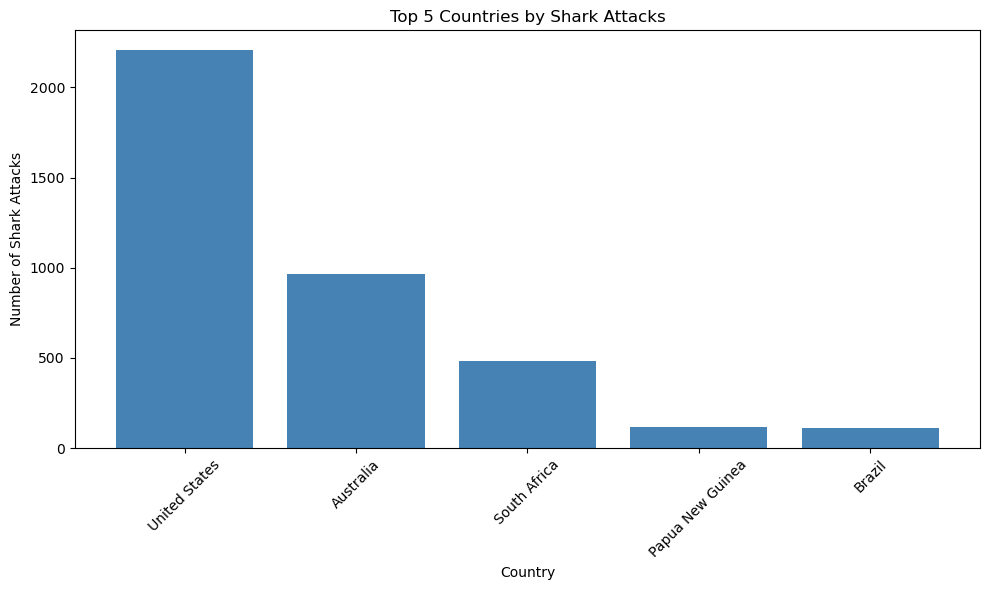

In [61]:
import matplotlib.pyplot as plt

# Select top 10 countries
top_10 = top_countries_df.head(5)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(top_10['Country'], top_10['Attack Count'], color='steelblue')
plt.xticks(rotation=45)
plt.xlabel('Country')
plt.ylabel('Number of Shark Attacks')
plt.title('Top 5 Countries by Shark Attacks')
plt.tight_layout()
plt.show()

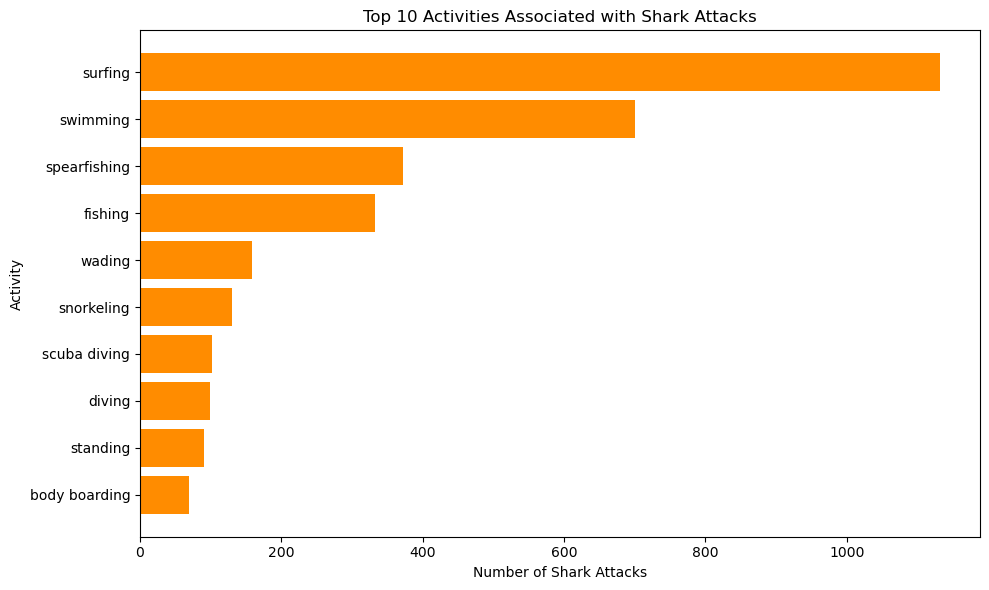

In [62]:
import matplotlib.pyplot as plt

# Assuming you've already created this DataFrame:
activity_risk = sharks.groupby('Activity').size().reset_index(name='Attack_Count').sort_values('Attack_Count', ascending=False)

# Select top 10 activities
top_activities = activity_risk.head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_activities['Activity'], top_activities['Attack_Count'], color='darkorange')
plt.xlabel('Number of Shark Attacks')
plt.ylabel('Activity')
plt.title('Top 10 Activities Associated with Shark Attacks')
plt.gca().invert_yaxis()  # Highest risk at the top
plt.tight_layout()
plt.show()